# 🐜 Segmentation analysis

✋ This notebook has been created and used to reproduce the leave segmentation analysis conducted on the ant videos by Anastasiia FIlippova under the supervision of Mackenzie Mathis.

👉 The segmentation masks used in the notebook were received with custom napari segmentation plugin written by Anastasiia Filippova (code can be found in the [original project repo](https://github.com/MMathisLab/Leaf_Ant_Analysis)).

For any questions, please reach out: anastasiia.filippova@epfl.ch

## Load the data from google drive:

- this assumes you have been granted access to the data. It will be shared with the publication.


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
folder_name = 'Ants-mackenzie-2024-02-11'
VideoType = 'mp4'

data_path = f'/content/drive/My Drive/{folder_name}/segmentation/'
data_path

'/content/drive/My Drive/Ants-mackenzie-2024-02-11/segmentation/'

## Let's look what is inside the segmentation folder:

In [23]:
os.listdir(data_path)

['ant_video_5', 'ant_video_4', 'ant_video_3', 'ant_video_2', 'ant_video_1']

In [24]:
os.listdir(f'{data_path}/ant_video_5')

['cropped_frames', 'masks']

## Import Dependencies

In [11]:
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import glob
import numpy as np
import seaborn as sns
import os
from PIL import Image

## Introduce helper functions:

In [25]:
def get_paths(data_path):

    masks_paths = sorted(glob.glob(f"{data_path}/masks/*"))
    image_paths = sorted(glob.glob(f"{data_path}/cropped_frames/*"))
    return masks_paths, image_paths

In [26]:
def extract_roi(masks, bottom=450):

    center = masks.shape[-1] // 2

    bottom_left = masks[:, bottom:, :center]
    bottom_right = masks[:, bottom:, center:]
    upper_left = masks[:, :bottom, :center]
    upper_right = masks[:, :bottom, center:]

    return bottom_left, bottom_right, upper_left, upper_right


def get_area(masks):
    return np.sum(masks, axis=(1, 2))

In [55]:
def plot_area(ax, area_right, area_left, color, label):

    plt.rcParams["figure.frameon"] = False
    cmap = plt.get_cmap("viridis")
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.plot(area_right, color=color, alpha=1, label = label)
    ax.plot(area_left, color="grey", alpha=1, linestyle="dashed")
    ax.set_ylim(-0.1, 0.7)
    ax.set_xlabel(r"Time (minutes)")
    ax.set_ylabel(r"Relative area")
    sns.despine(
        trim=True,
    )
    plt.legend()
    return ax

In [56]:
def overlay_segmentation_cv(ind, image_paths, masks, color, alpha=0.4):
    image = cv2.imread(image_paths[ind])
    print(image_paths[ind])
    mask = masks[ind]
    overlay = np.zeros_like(image)
    overlay[mask > 0] = color
    cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0, image)

    return image

In [57]:
def get_results(data_path):
    masks_paths, image_paths = get_paths(data_path)
    if 'ant_video_1' in data_path:
      masks_paths = masks_paths[::2]
      image_paths = image_paths[::2]
    masks = np.array([np.load(i) for i in masks_paths])
    print(masks.shape)
    bottom_left, bottom_right, upper_left, upper_right = extract_roi(masks)

    print(f"Number of masks: {len(masks_paths)}, Number of images: {len(image_paths)}")
    assert len(masks_paths) == len(image_paths)

    area_bottom_left = get_area(bottom_left)
    area_bottom_right = get_area(bottom_right)
    area_upper_left = get_area(upper_left)
    area_upper_right = get_area(upper_right)

    area_right = area_upper_right / (area_upper_right + area_bottom_right)
    area_left = area_upper_left / (area_upper_left + area_bottom_left)

    return area_right, area_left, image_paths, masks

In [50]:
import matplotlib.colors as mcolors


def hex_to_bgr(hex_color):
    """Convert a hexadecimal color string to a BGR tuple."""
    hex_color = hex_color.lstrip("#")
    lv = len(hex_color)
    return tuple(int(hex_color[i : i + lv // 3], 16) for i in range(0, lv, lv // 3))[
        ::-1
    ]


def convert_to_bgr(color):
    css4_colors = mcolors.CSS4_COLORS

    if isinstance(color, str):
        hex_color = css4_colors.get(color.lower())
        if hex_color:
            bgr = hex_to_bgr(hex_color)
        else:
            print(f"Named color '{color}' is not in the Matplotlib CSS4_COLORS list.")
    elif isinstance(color, tuple) and len(color) == 4:
        # Convert RGBA to BGR (ignore alpha channel)
        bgr = (int(color[2] * 255), int(color[1] * 255), int(color[0] * 255))
    else:
        print(f"Input '{color}' is not recognized as a valid color format.")

    return bgr

## Let's compute relative area for all videos:

In [51]:
results = {}
for path in glob.glob(f"{data_path}/*_video_*"):
    print(path)
    results[path.split("/")[-1]] = get_results(path)

/content/drive/My Drive/Ants-mackenzie-2024-02-11/segmentation/ant_video_5
(61, 710, 1100)
Number of masks: 61, Number of images: 61
/content/drive/My Drive/Ants-mackenzie-2024-02-11/segmentation/ant_video_4
(123, 710, 1100)
Number of masks: 123, Number of images: 123
/content/drive/My Drive/Ants-mackenzie-2024-02-11/segmentation/ant_video_3
(123, 710, 1100)
Number of masks: 123, Number of images: 123
/content/drive/My Drive/Ants-mackenzie-2024-02-11/segmentation/ant_video_2
(122, 710, 1100)
Number of masks: 122, Number of images: 122
/content/drive/My Drive/Ants-mackenzie-2024-02-11/segmentation/ant_video_1
(118, 710, 1100)
Number of masks: 118, Number of images: 118


In [52]:
colors = ["purple", "cyan", "darkorange", "darkblue", "salmon"]

## Plot the results:

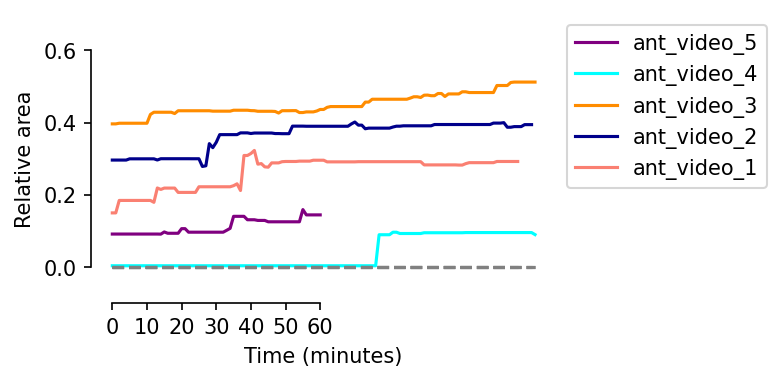

In [58]:
fig = plt.figure(figsize=(4, 2.5), dpi=150)
ax = fig.add_subplot(111)
video_to_colors = {}
for i, (key, values) in enumerate(results.items()):
    ax = plot_area(ax, values[0], values[1], color=colors[i], label = key)
    video_to_colors[key] = convert_to_bgr(colors[i])
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

/content/drive/My Drive/Ants-mackenzie-2024-02-11/segmentation/ant_video_5/cropped_frames/frame_0000.png
/content/drive/My Drive/Ants-mackenzie-2024-02-11/segmentation/ant_video_5/cropped_frames/frame_3600.png
/content/drive/My Drive/Ants-mackenzie-2024-02-11/segmentation/ant_video_4/cropped_frames/frame_0000.png
/content/drive/My Drive/Ants-mackenzie-2024-02-11/segmentation/ant_video_4/cropped_frames/frame_7320.png
/content/drive/My Drive/Ants-mackenzie-2024-02-11/segmentation/ant_video_3/cropped_frames/frame_0000.png
/content/drive/My Drive/Ants-mackenzie-2024-02-11/segmentation/ant_video_3/cropped_frames/frame_7320.png
/content/drive/My Drive/Ants-mackenzie-2024-02-11/segmentation/ant_video_2/cropped_frames/frame_0000.png
/content/drive/My Drive/Ants-mackenzie-2024-02-11/segmentation/ant_video_2/cropped_frames/frame_7260.png
/content/drive/My Drive/Ants-mackenzie-2024-02-11/segmentation/ant_video_1/cropped_frames/frame_0000.png
/content/drive/My Drive/Ants-mackenzie-2024-02-11/segme

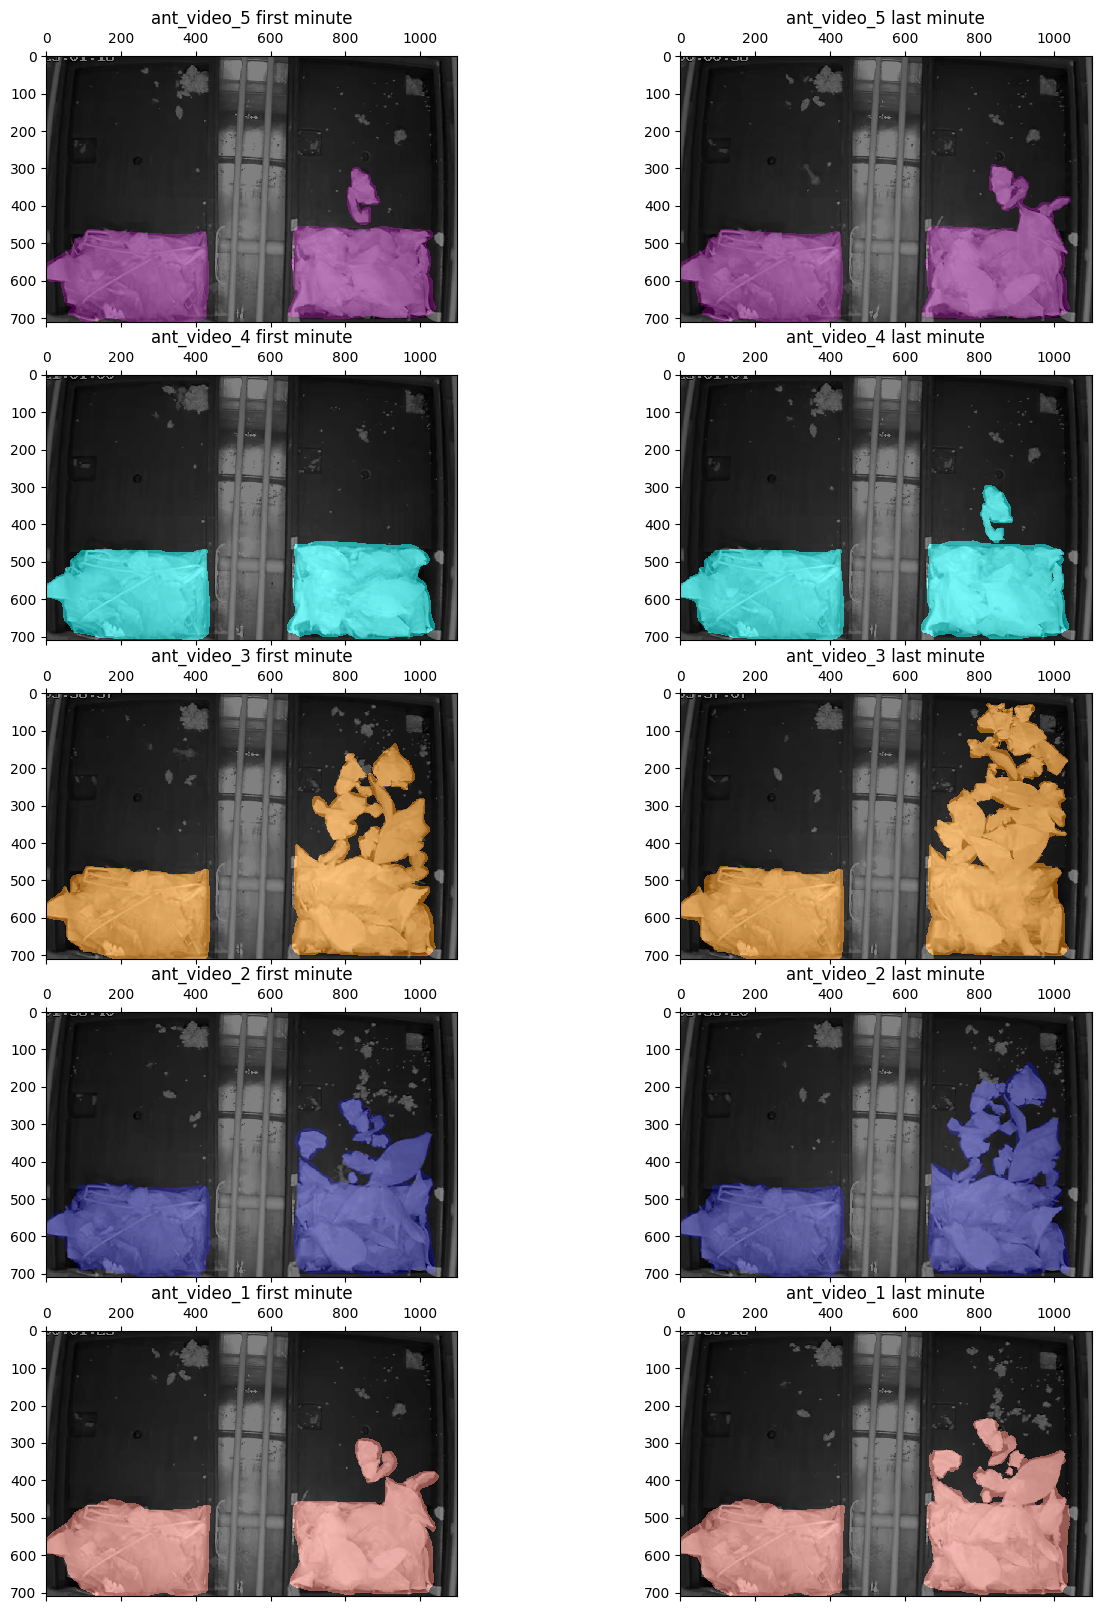

In [74]:
fig, axs = plt.subplots(5, 2, figsize=(15, 20))

for i, key in enumerate(results):
    image_paths = results[key][2]
    masks = results[key][3]
    image_mask_first = overlay_segmentation_cv(
        0, image_paths, masks, color=video_to_colors[key], alpha=0.5
    )
    image_mask_last = overlay_segmentation_cv(
        len(image_paths) - 1, image_paths, masks, color=video_to_colors[key], alpha=0.5
    )
    image_mask_first = cv2.cvtColor(image_mask_first, cv2.COLOR_BGR2RGB)
    image_mask_last = cv2.cvtColor(image_mask_last, cv2.COLOR_BGR2RGB)

    axs[i][0].matshow(image_mask_first)
    axs[i][1].matshow(image_mask_last)
    axs[i][0].set_title(f'{key} first minute')
    axs[i][1].set_title(f'{key} last minute')